In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns


In [ ]:
from pathlib import Path
df = pd.read_csv(Path("..") / "data" / "raw" / "city_day.csv")

In [9]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 4.3 MB


In [11]:
df.shape

(29531, 16)

In [14]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='str')

In [15]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [16]:
df['AQI'].isnull().sum()

np.int64(4681)

In [17]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [18]:
cols = ['PM2.5', 'PM10', 'CO', 'O3', 'NH3', 'AQI']
df = df[cols]

In [19]:
df.isnull().sum()

PM2.5     4598
PM10     11140
CO        2059
O3        4022
NH3      10328
AQI       4681
dtype: int64

In [20]:
df = df.dropna(subset=['AQI'])

In [21]:
df.fillna(df.mean(), inplace=True)

,PM2.5,PM10,CO,O3,NH3,AQI
28,83.13,118.454435,6.93,59.76,23.848366,209.0
29,79.84,118.454435,13.85,97.07,23.848366,328.0
30,94.52,118.454435,24.39,111.33,23.848366,514.0
31,135.99,118.454435,43.48,102.70,23.848366,782.0
32,178.33,118.454435,54.56,107.38,23.848366,914.0
...,...,...,...,...,...,...
29526,15.02,50.940000,0.47,23.30,12.470000,41.0
29527,24.38,74.090000,0.52,30.14,11.990000,70.0
29528,22.91,65.730000,0.48,30.96,10.710000,68.0
29529,16.64,49.970000,0.52,28.30,10.030000,54.0


In [22]:
df.isnull().sum()

PM2.5    0
PM10     0
CO       0
O3       0
NH3      0
AQI      0
dtype: int64

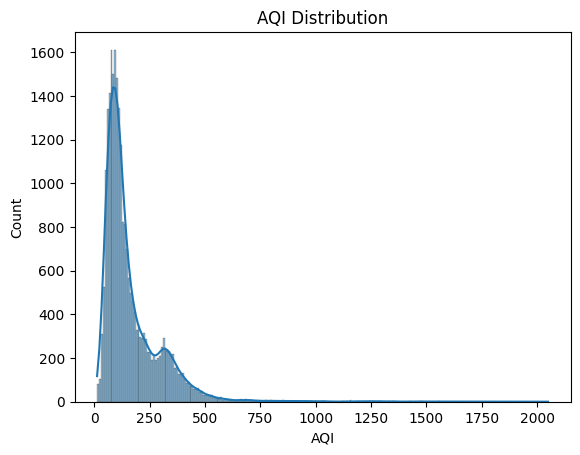

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['AQI'], kde=True)
plt.title("AQI Distribution")
plt.show()

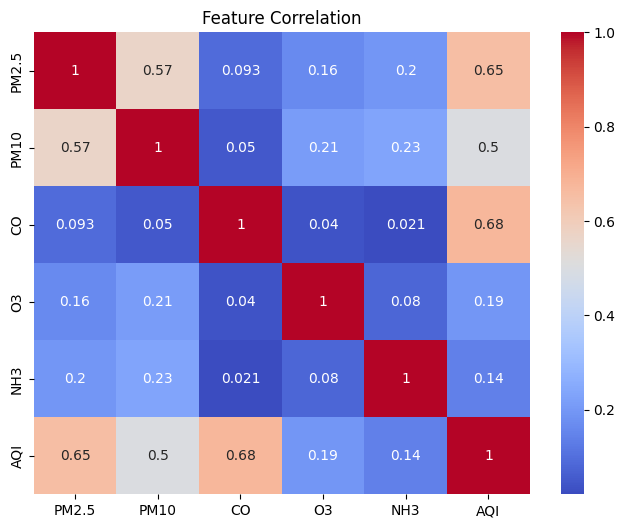

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

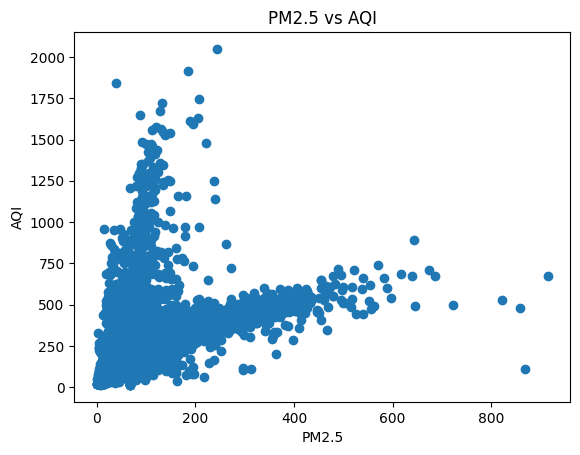

In [25]:
plt.scatter(df['PM2.5'], df['AQI'])
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.title("PM2.5 vs AQI")
plt.show()

In [26]:
df = df[df['AQI'] < 500]

<Axes: xlabel='AQI', ylabel='Count'>

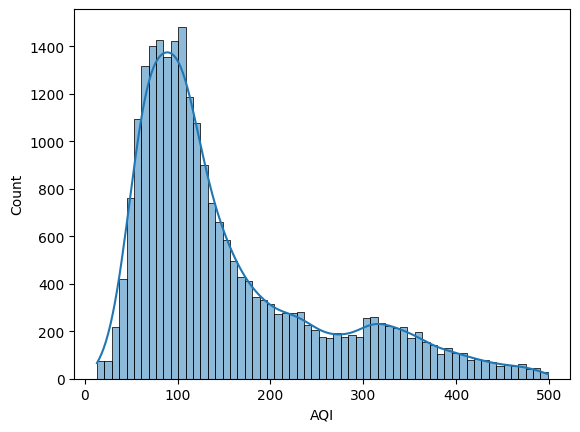

In [27]:
sns.histplot(df['AQI'], kde=True)

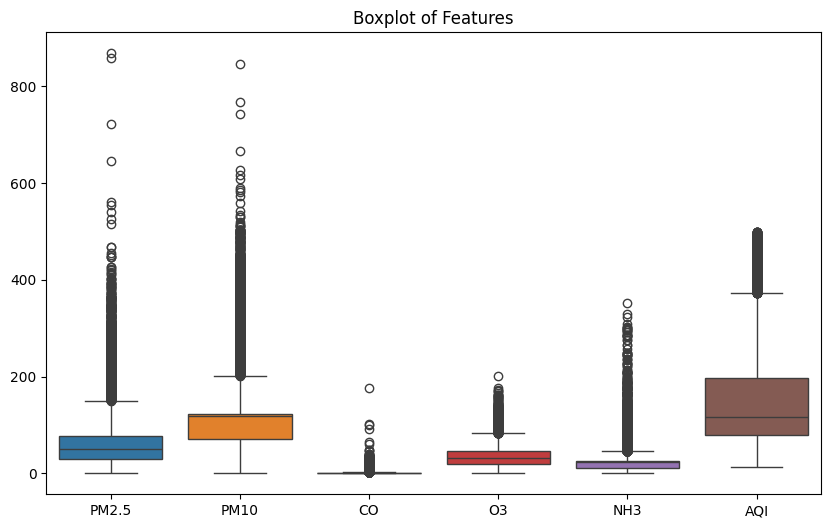

In [28]:

plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot of Features")
plt.show()


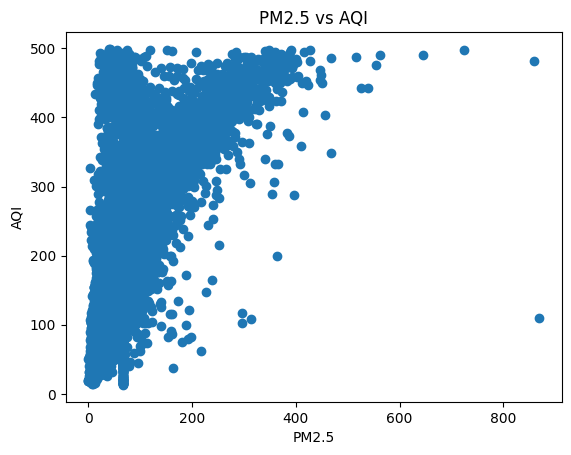

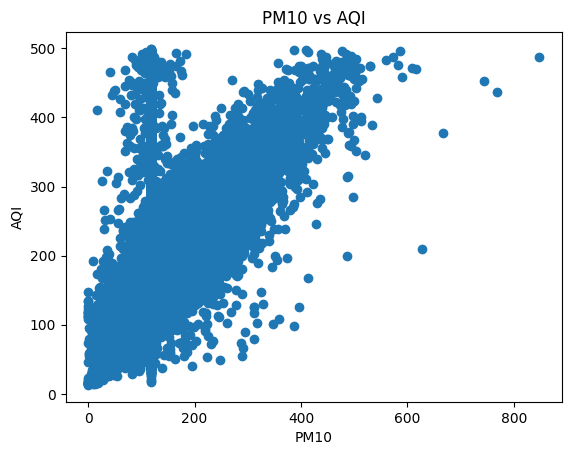

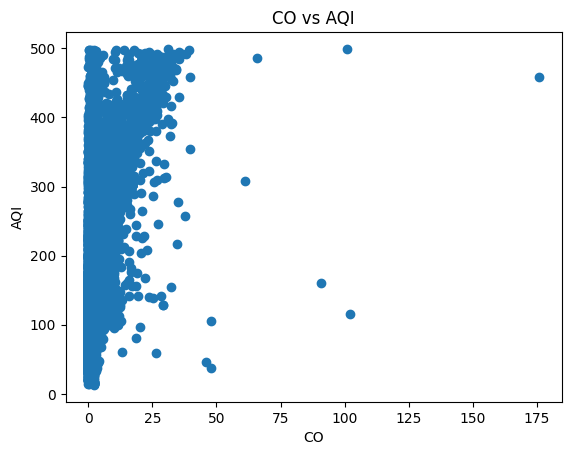

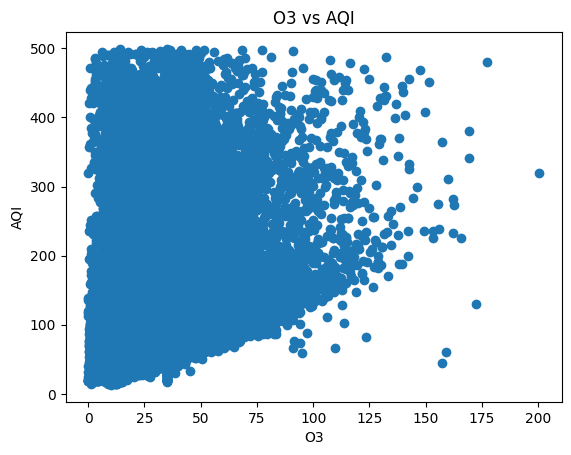

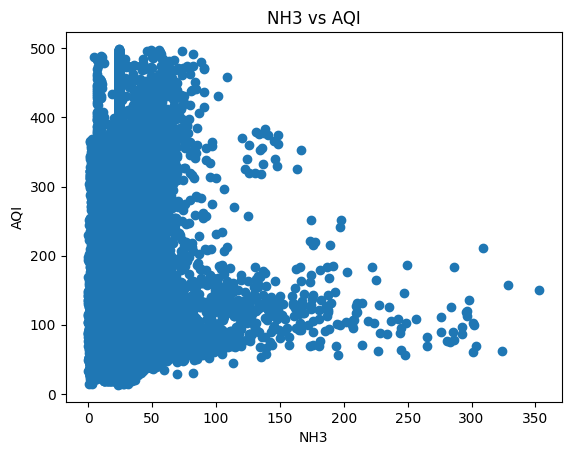

In [29]:
features = ['PM2.5', 'PM10', 'CO', 'O3', 'NH3']

for col in features:
    plt.scatter(df[col], df['AQI'])
    plt.xlabel(col)
    plt.ylabel("AQI")
    plt.title(f"{col} vs AQI")
    plt.show()

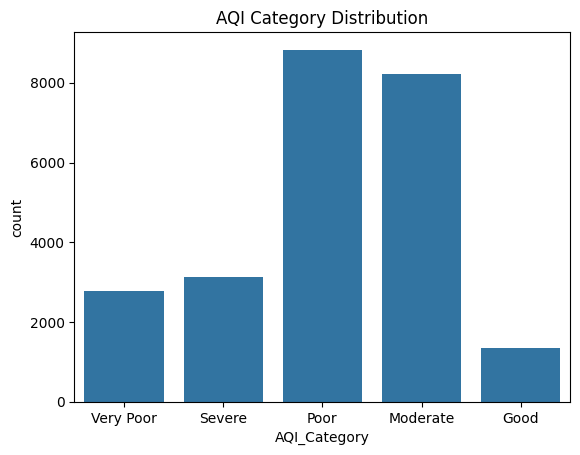

In [30]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Poor"
    elif aqi <= 300:
        return "Very Poor"
    else:
        return "Severe"

df['AQI_Category'] = df['AQI'].apply(categorize_aqi)

sns.countplot(x='AQI_Category', data=df)
plt.title("AQI Category Distribution")
plt.show()

In [32]:
from pathlib import Path

output_path = Path("data") / "processed" / "cleaned_data.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(output_path, index=False)
print(f"Saved cleaned data to: {output_path.resolve()}")

Saved cleaned data to: D:\AirQuality_AI_IoT\notebooks\data\processed\cleaned_data.csv
